In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
cols = ['area', 'perimeter', 'compactness', 'length',
        'width', 'asymetry', 'groove', 'class']

df = pd.read_csv("seeds_dataset.txt", names = cols, sep="\s+")

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2690/2263992088.py:4: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv("seeds_dataset.txt", names = cols, sep="\s+")


In [5]:
df.head()

,area,perimeter,compactness,length,width,asymetry,groove,class
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


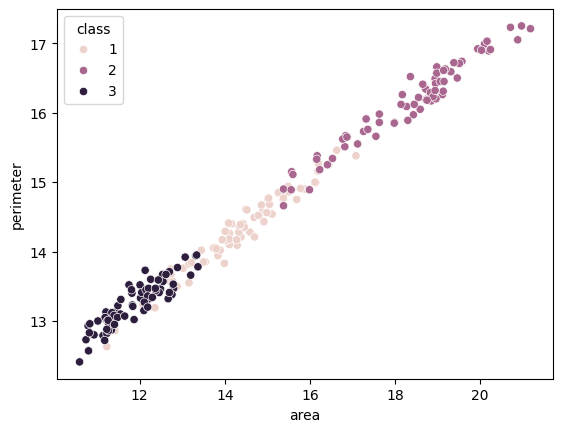

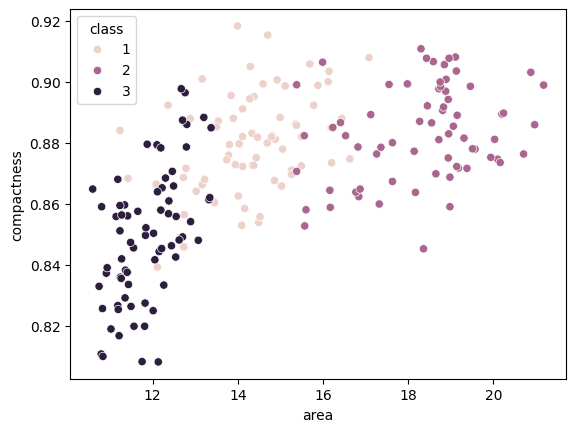

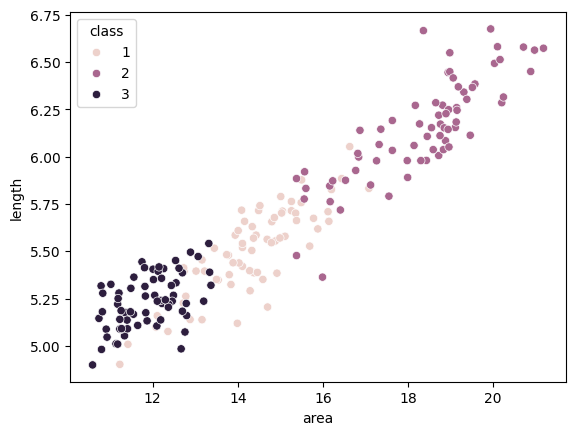

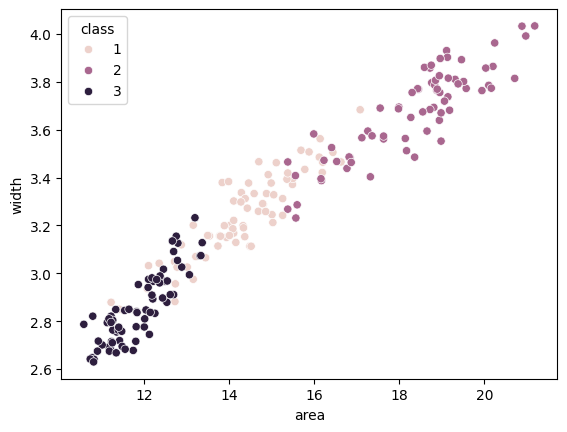

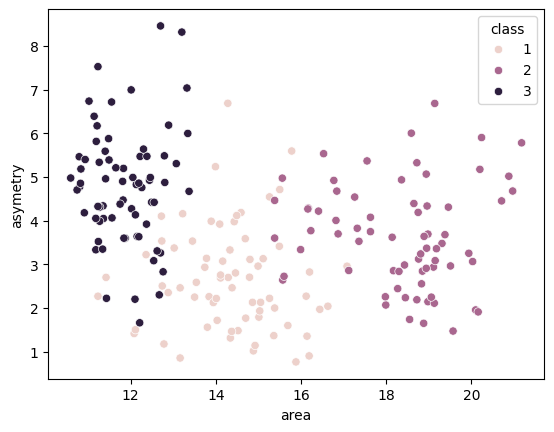

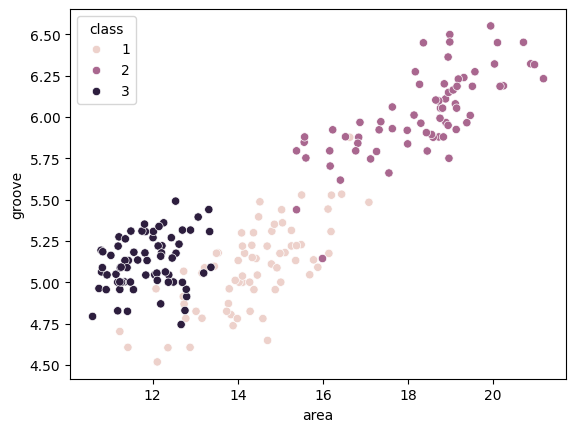

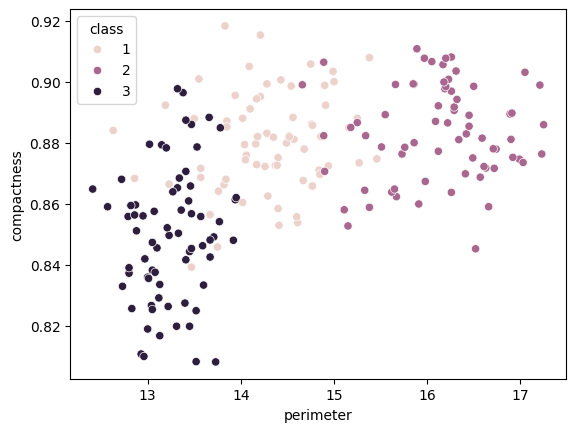

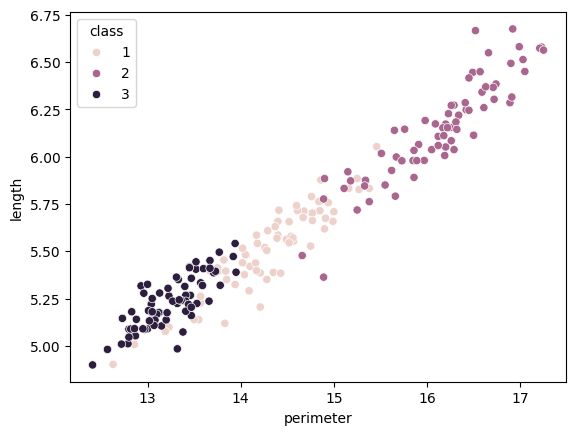

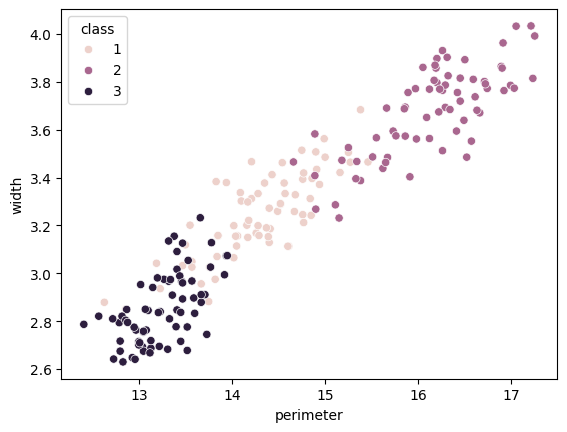

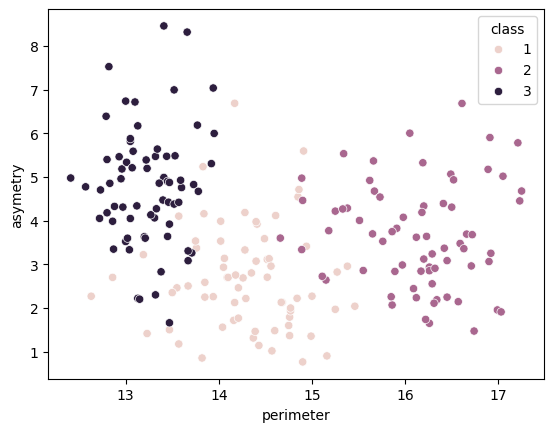

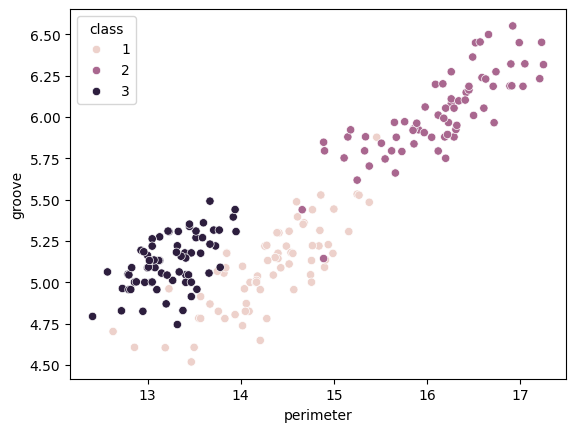

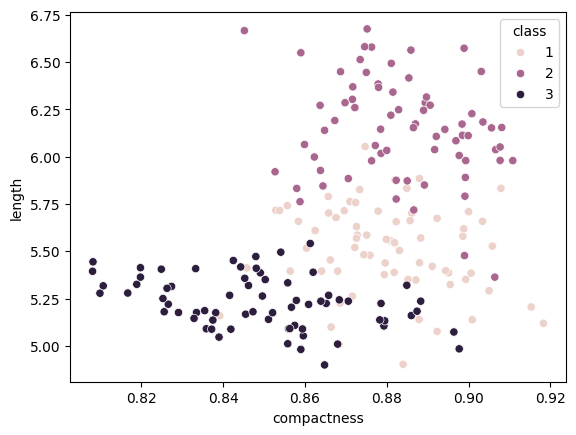

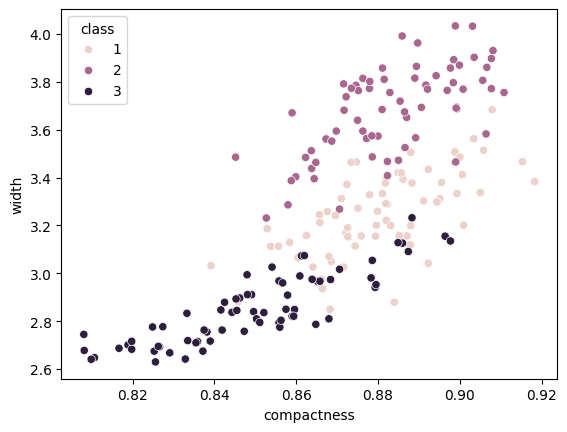

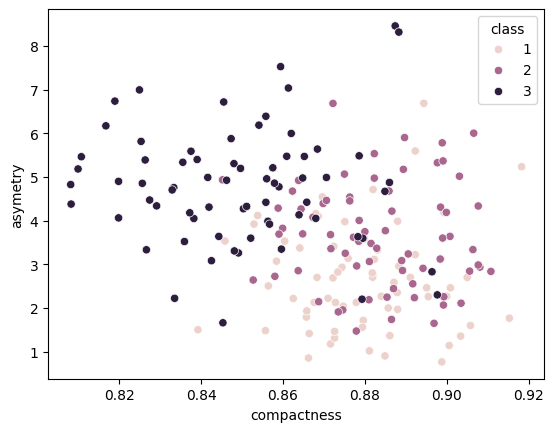

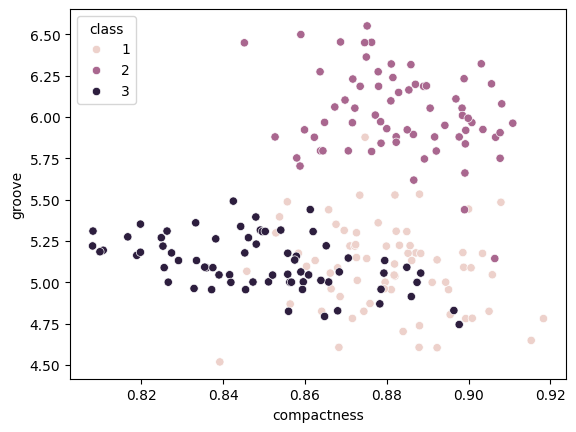

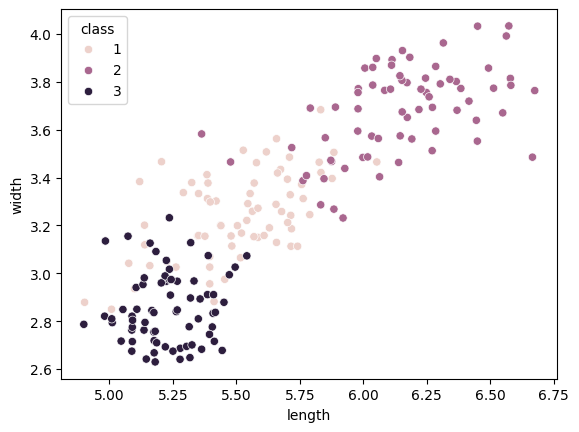

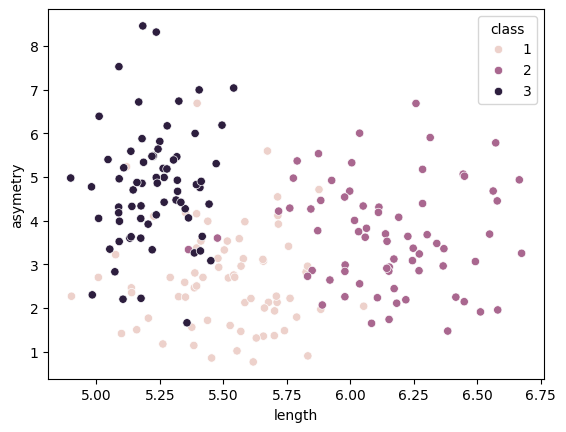

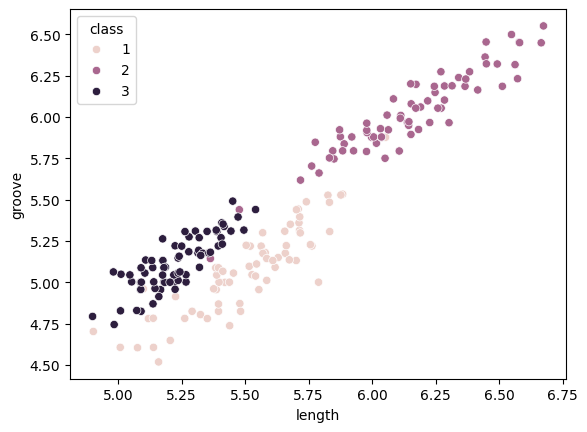

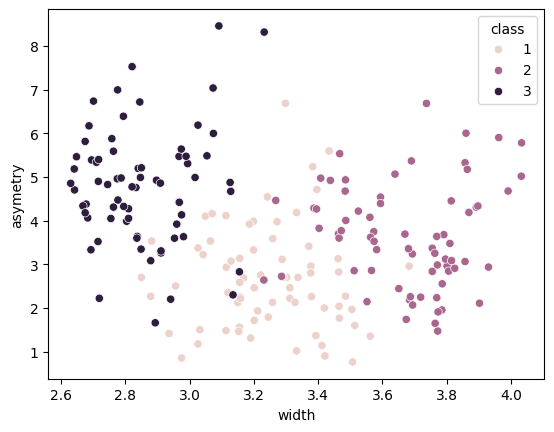

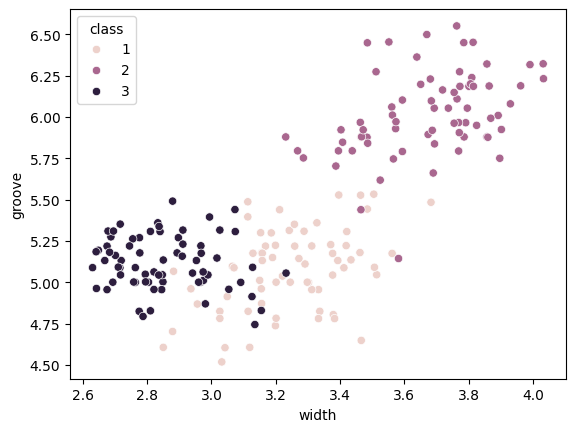

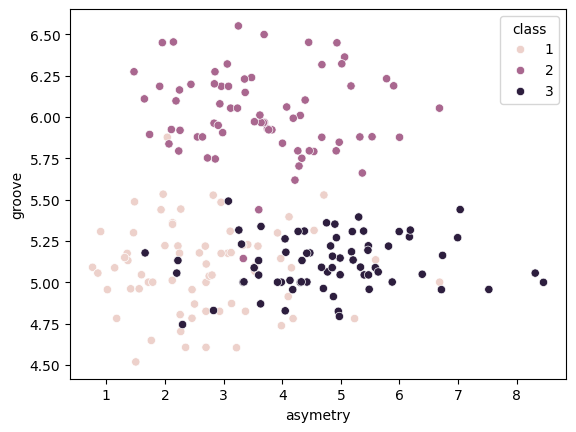

In [8]:
for i in range(len(cols) - 1):
  for j in range(i+1, len(cols) - 1):

    x_label = cols[i]
    y_label = cols[j]

    sns.scatterplot(x=x_label, y=y_label, hue='class', data=df)
    plt.show()

# Clustering

In [9]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [20]:
feature1_name = 'perimeter'
feature2_name = 'asymetry'
X_features = df[[feature1_name, feature2_name]].values

In [13]:
kmeans = KMeans(n_clusters=3).fit(x)

In [14]:
clusters = kmeans.labels_

In [21]:
cluster_df = pd.DataFrame(np.hstack((X_features, clusters.reshape(-1,1))), columns=[feature1_name, feature2_name, 'class'])

[]

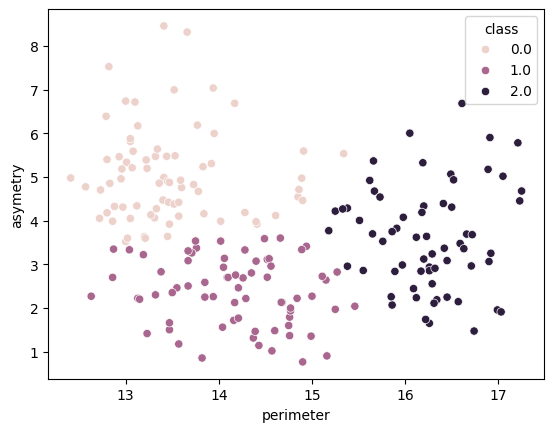

In [23]:
sns.scatterplot(x=feature1_name, y=feature2_name, hue='class', data= cluster_df)
plt.plot()

# Higher dimensions


In [24]:
X = df[cols[:-1]].values

In [40]:
kmeans = KMeans(n_clusters=3).fit(X)
cluster_df = pd.DataFrame(np.hstack((X, kmeans.labels_.reshape(-1,1))), columns=df.columns)

[]

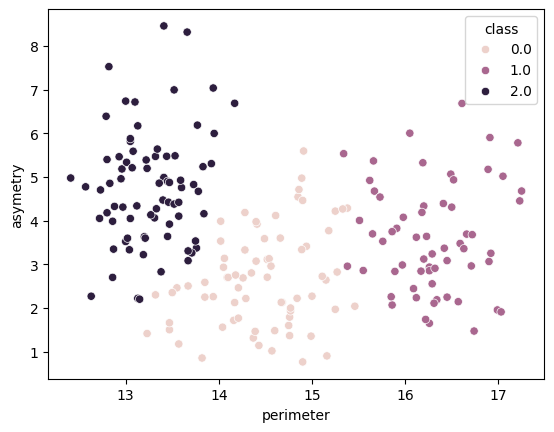

In [41]:
sns.scatterplot(x=feature1_name, y=feature2_name, hue='class', data= cluster_df)
plt.plot()

# PCA


In [34]:
from sklearn.decomposition import PCA

In [35]:
pca = PCA(n_components=2)
transforme_x = pca.fit_transform(X)

In [36]:
X.shape

(210, 7)

In [37]:
transforme_x.shape

(210, 2)

In [38]:
transforme_x[:5]

array([[ 0.66344838, -1.41732098],
       [ 0.31566651, -2.68922915],
       [-0.6604993 , -1.13150635],
       [-1.0552759 , -1.62119002],
       [ 1.61999921, -2.18338442]])

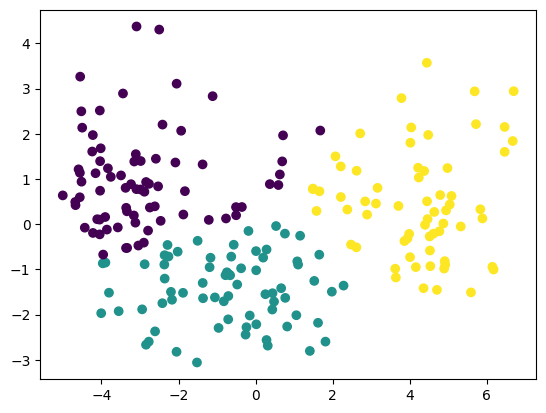

In [39]:
plt.scatter(transforme_x[:, 0], transforme_x[:, 1], c=clusters)
plt.show()

In [42]:
kmeans_pca_df = pd.DataFrame(np.hstack((transforme_x, kmeans.labels_.reshape(-1,1))), columns=['PC1', 'PC2', 'class'])

In [43]:
truth_pca_df = pd.DataFrame(np.hstack((transforme_x, df['class'].values.reshape(-1,1))), columns=['PC1', 'PC2', 'class'])

[]

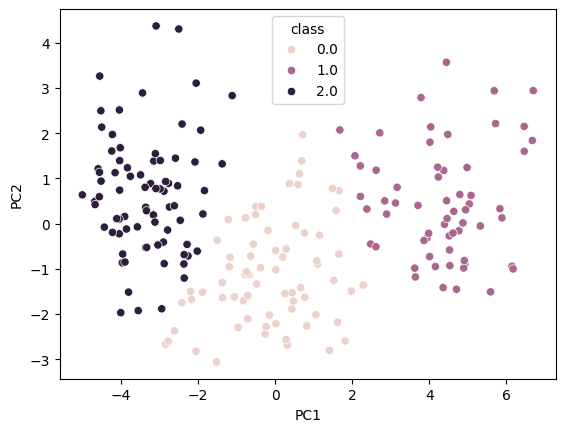

In [45]:
sns.scatterplot(x='PC1', y='PC2', hue='class', data= kmeans_pca_df)
plt.plot()

[]

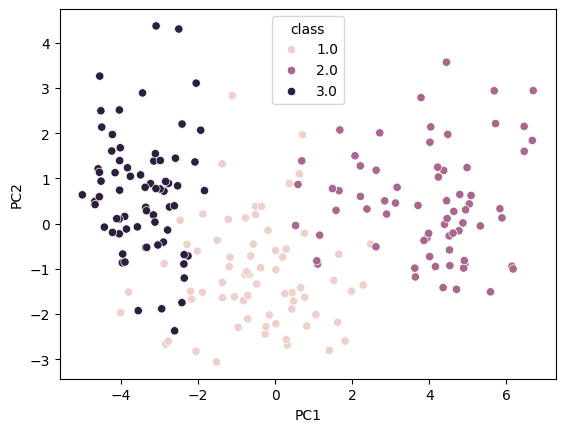

In [47]:
sns.scatterplot(x='PC1', y='PC2', hue='class', data= truth_pca_df)
plt.plot()